# Backtest Output Analysis

This notebook analyzes the artifacts generated by `backtest_model.py`.

Expected files:
- `training/reports/backtest/equity_curve.csv`
- `training/reports/backtest/trades.csv`
- `training/reports/backtest/backtest_metrics.json`


In [22]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path.cwd().parent
BACKTEST_DIR = BASE_DIR / 'reports' / 'backtest'

equity_path = BACKTEST_DIR / 'equity_curve.csv'
trades_path = BACKTEST_DIR / 'trades.csv'
metrics_path = BACKTEST_DIR / 'backtest_metrics.json'

print('BACKTEST_DIR =', BACKTEST_DIR)
print('equity_curve.csv exists:', equity_path.exists())
print('trades.csv exists:', trades_path.exists())
print('backtest_metrics.json exists:', metrics_path.exists())


BACKTEST_DIR = /home/lucas/Invest/training/reports/backtest
equity_curve.csv exists: True
trades.csv exists: True
backtest_metrics.json exists: True


## 1. Backtest metrics

In [23]:
bt_metrics = None
if metrics_path.exists():
    with open(metrics_path, 'r', encoding='utf-8') as f:
        bt_metrics = json.load(f)
    metrics_df = pd.DataFrame([
        {'metric': k, 'value': v} for k, v in bt_metrics.items()
    ])
    display(metrics_df)
else:
    print('backtest_metrics.json not found.')


,metric,value
0,initial_capital,100000.000000
1,final_capital,516098.516552
2,total_return,4.160985
3,avg_daily_return,0.005304
4,daily_volatility,0.069537
5,annualized_sharpe,1.210755
6,max_drawdown,-0.915206
7,positive_day_ratio,0.547406
8,num_days,559.000000
9,top_n_longs,5.000000


## 2. Equity curve overview

In [24]:
equity = None
if equity_path.exists():
    equity = pd.read_csv(equity_path, parse_dates=['trade_date'])
    display(equity.head())
    print('Rows:', len(equity))
    print('Date range:', equity['trade_date'].min(), '->', equity['trade_date'].max())
else:
    print('equity_curve.csv not found.')


,trade_date,start_capital,daily_return,end_capital,drawdown,num_positions
0,2023-12-27,100000.000000,-0.069290,93071.028000,-0.069290,10
1,2023-12-28,93071.028000,0.016053,94565.097399,-0.054349,10
2,2024-01-02,94565.097399,0.002537,94805.037420,-0.051950,10
3,2024-01-03,94805.037420,-0.066033,88544.730499,-0.114553,10
4,2024-01-04,88544.730499,0.013809,89767.468589,-0.102325,10


Rows: 559
Date range: 2023-12-27 00:00:00 -> 2026-03-24 00:00:00


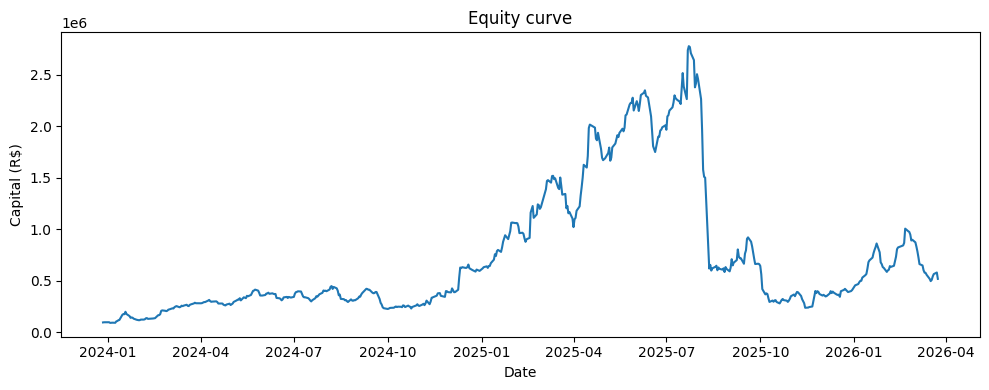

In [25]:
if equity is not None:
    plt.figure(figsize=(10, 4))
    plt.plot(equity['trade_date'], equity['end_capital'])
    plt.title('Equity curve')
    plt.xlabel('Date')
    plt.ylabel('Capital (R$)')
    plt.tight_layout()
    plt.show()


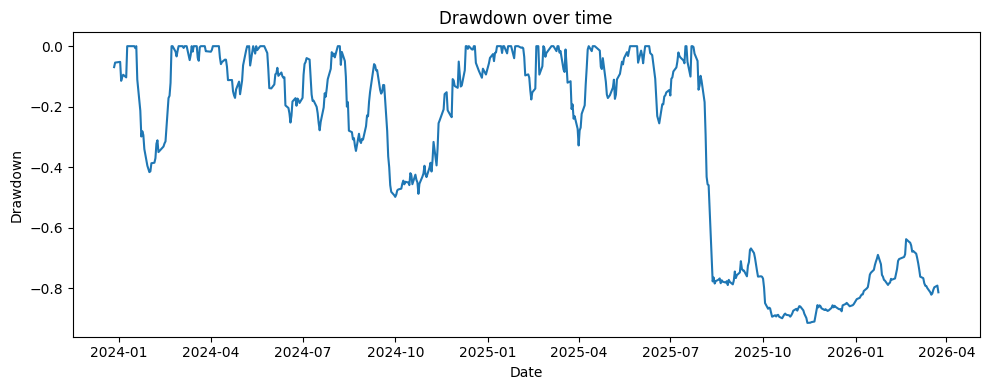

In [26]:
if equity is not None:
    plt.figure(figsize=(10, 4))
    plt.plot(equity['trade_date'], equity['drawdown'])
    plt.title('Drawdown over time')
    plt.xlabel('Date')
    plt.ylabel('Drawdown')
    plt.tight_layout()
    plt.show()


## 3. Daily return distribution

count    559.000000
mean       0.005304
std        0.069537
min       -0.442102
25%       -0.025603
50%        0.005847
75%        0.037695
max        0.607814
Name: daily_return, dtype: float64

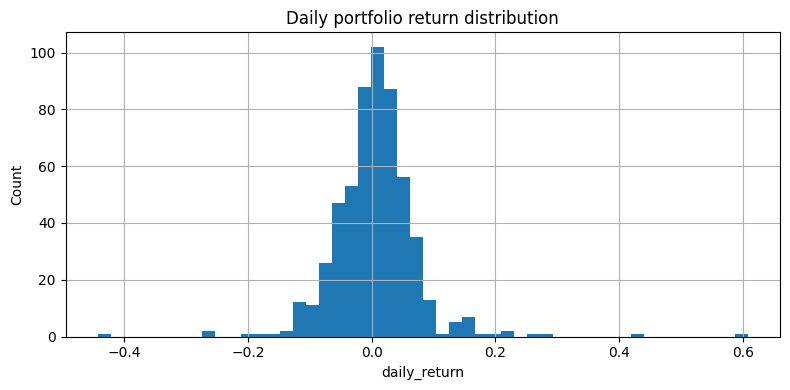

In [27]:
if equity is not None:
    display(equity['daily_return'].describe())
    
    plt.figure(figsize=(8, 4))
    equity['daily_return'].hist(bins=50)
    plt.title('Daily portfolio return distribution')
    plt.xlabel('daily_return')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


trade_date
2025-04-30    0.513833
2025-05-31    0.288875
2025-06-30   -0.066948
2025-07-31    0.247482
2025-08-31   -0.755542
2025-09-30    0.076666
2025-10-31   -0.473008
2025-11-30    0.063083
2025-12-31    0.103539
2026-01-31    0.529139
2026-02-28    0.437692
2026-03-31   -0.423695
Freq: ME, Name: daily_return, dtype: float64

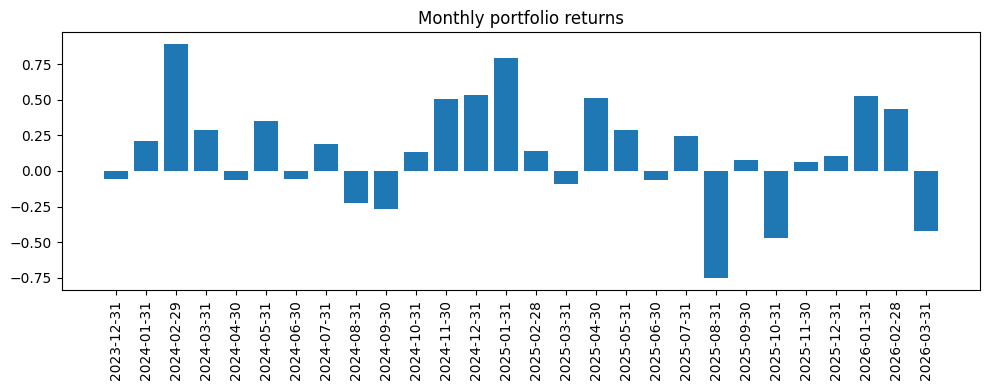

In [28]:
if equity is not None:
    equity = equity.copy()
    equity['cummax_capital'] = equity['end_capital'].cummax()
    equity['wealth_index'] = equity['end_capital'] / equity['end_capital'].iloc[0]
    
    monthly = (
        equity.set_index('trade_date')['daily_return']
        .resample('ME')
        .apply(lambda x: (1 + x).prod() - 1)
    )
    display(monthly.tail(12))
    
    plt.figure(figsize=(10, 4))
    plt.bar(monthly.index.astype(str), monthly.values)
    plt.title('Monthly portfolio returns')
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


## 4. Best and worst days

In [29]:
if equity is not None:
    print('Best 10 days')
    display(equity.nlargest(10, 'daily_return'))
    print('Worst 10 days')
    display(equity.nsmallest(10, 'daily_return'))


Best 10 days


,trade_date,start_capital,daily_return,end_capital,drawdown,num_positions,cummax_capital,wealth_index
478,2025-11-24,2.477583e+05,0.607814,3.983493e+05,-0.856481,10,2.775590e+06,4.280057
11,2024-01-15,1.163227e+05,0.439242,1.674165e+05,0.000000,10,1.674165e+05,1.798804
240,2024-12-10,4.103247e+05,0.291780,5.300494e+05,0.000000,10,5.300494e+05,5.695106
286,2025-02-18,9.139878e+05,0.268255,1.159169e+06,0.000000,10,1.159169e+06,12.454676
390,2025-07-22,2.261615e+06,0.210351,2.737349e+06,0.000000,10,2.737349e+06,29.411402
34,2024-02-19,1.345153e+05,0.209280,1.626666e+05,-0.171542,10,1.963487e+05,1.747768
37,2024-02-22,1.724745e+05,0.190738,2.053719e+05,0.000000,10,2.053719e+05,2.206615
241,2024-12-11,5.300494e+05,0.180934,6.259533e+05,0.000000,10,6.259533e+05,6.725544
231,2024-11-27,3.412287e+05,0.164630,3.974052e+05,-0.108897,10,4.459698e+05,4.269913
536,2026-02-20,8.652950e+05,0.159951,1.003700e+06,-0.638383,10,2.775590e+06,10.784233


Worst 10 days


,trade_date,start_capital,daily_return,end_capital,drawdown,num_positions,cummax_capital,wealth_index
404,2025-08-11,1.499556e+06,-0.442102,8.365998e+05,-0.698587,10,2.775590e+06,8.988831
405,2025-08-12,8.365998e+05,-0.263418,6.162247e+05,-0.777984,10,2.775590e+06,6.621015
443,2025-10-03,5.596774e+05,-0.255202,4.168466e+05,-0.849817,10,2.775590e+06,4.478801
401,2025-08-06,1.962327e+06,-0.196778,1.576184e+06,-0.432126,10,2.775590e+06,16.935286
186,2024-09-23,3.884958e+05,-0.174347,3.207627e+05,-0.280752,10,4.459698e+05,3.446429
473,2025-11-14,2.796848e+05,-0.158506,2.353530e+05,-0.915206,10,2.775590e+06,2.528746
400,2025-08-05,2.261755e+06,-0.132387,1.962327e+06,-0.293005,10,2.775590e+06,21.084193
442,2025-10-02,6.417596e+05,-0.127902,5.596774e+05,-0.798357,10,2.775590e+06,6.013444
520,2026-01-27,7.739772e+05,-0.126734,6.758881e+05,-0.756489,10,2.775590e+06,7.262067
444,2025-10-06,4.168466e+05,-0.123908,3.651959e+05,-0.868426,10,2.775590e+06,3.923841


## 5. Trades overview

In [30]:
trades = None
if trades_path.exists():
    trades = pd.read_csv(trades_path, parse_dates=['trade_date'])
    display(trades.head())
    print('Rows:', len(trades))
else:
    print('trades.csv not found.')


,trade_date,symbol,target_5d,target_up_5d,pred_proba_up_5d,side,weight,position_return,start_capital,daily_portfolio_return
0,2023-12-27,BGIP3,-0.010745,0,0.645738,long,0.2,-0.010745,100000.0,-0.06929
1,2023-12-27,GSHP3,-0.187638,0,0.630914,long,0.2,-0.187638,100000.0,-0.06929
2,2023-12-27,CEEB3,0.012017,1,0.534586,long,0.2,0.012017,100000.0,-0.06929
3,2023-12-27,VSTE3,-0.011111,0,0.531997,long,0.2,-0.011111,100000.0,-0.06929
4,2023-12-27,PGMN3,-0.100515,0,0.525789,long,0.2,-0.100515,100000.0,-0.06929


Rows: 5590


,side,mean_position_return,median_position_return,count
0,long,0.000138,0.0,2795
1,short,0.007165,-0.0,2795


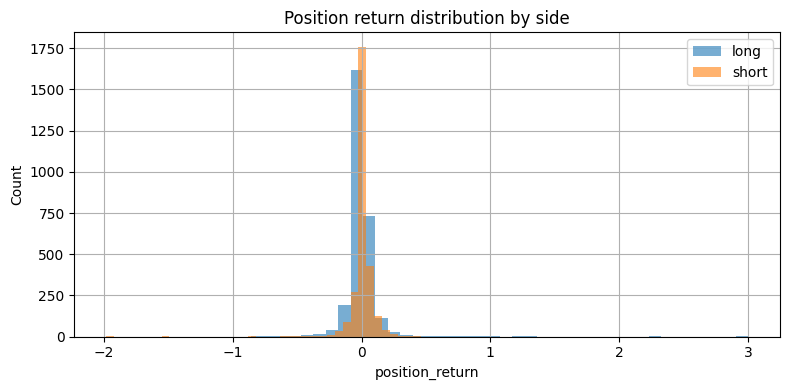

In [31]:
if trades is not None:
    side_summary = trades.groupby('side').agg(
        mean_position_return=('position_return', 'mean'),
        median_position_return=('position_return', 'median'),
        count=('position_return', 'size'),
    ).reset_index()
    display(side_summary)
    
    plt.figure(figsize=(8, 4))
    for side in sorted(trades['side'].dropna().unique()):
        trades.loc[trades['side'] == side, 'position_return'].hist(bins=40, alpha=0.6, label=side)
    plt.title('Position return distribution by side')
    plt.xlabel('position_return')
    plt.ylabel('Count')
    plt.legend()
    plt.tight_layout()
    plt.show()


## 6. Confidence analysis

,side,mean_pred_proba,mean_position_return,count
0,long,0.566008,0.000138,2795
1,short,0.474148,0.007165,2795


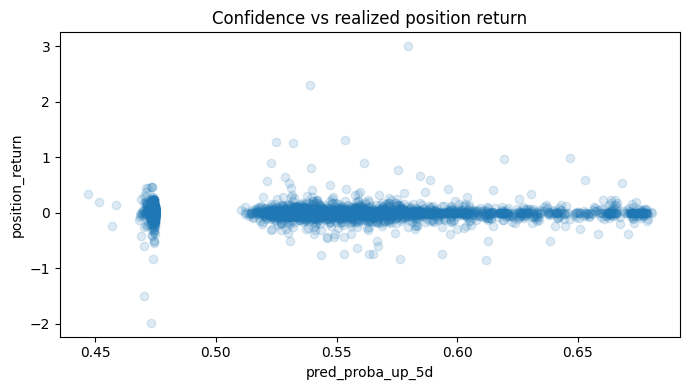

In [32]:
if trades is not None and 'pred_proba_up_5d' in trades.columns:
    confidence = trades.groupby('side').agg(
        mean_pred_proba=('pred_proba_up_5d', 'mean'),
        mean_position_return=('position_return', 'mean'),
        count=('pred_proba_up_5d', 'size'),
    ).reset_index()
    display(confidence)
    
    plt.figure(figsize=(7, 4))
    plt.scatter(trades['pred_proba_up_5d'], trades['position_return'], alpha=0.15)
    plt.title('Confidence vs realized position return')
    plt.xlabel('pred_proba_up_5d')
    plt.ylabel('position_return')
    plt.tight_layout()
    plt.show()
else:
    print('pred_proba_up_5d not found in trades.csv.')


## 7. Rolling diagnostics

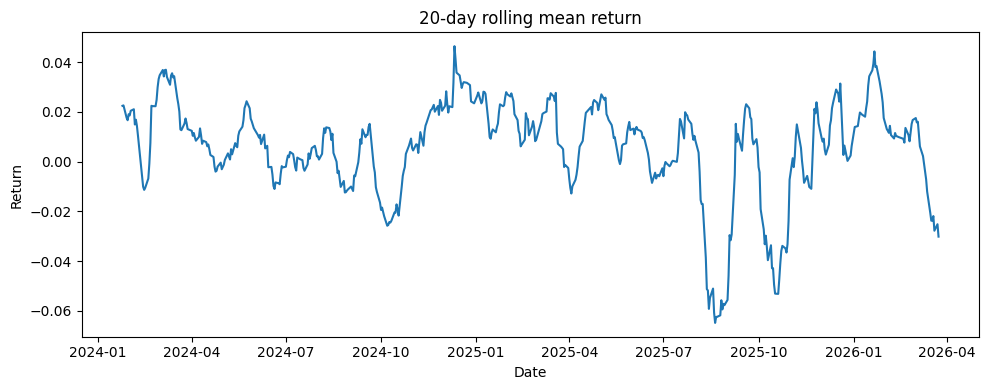

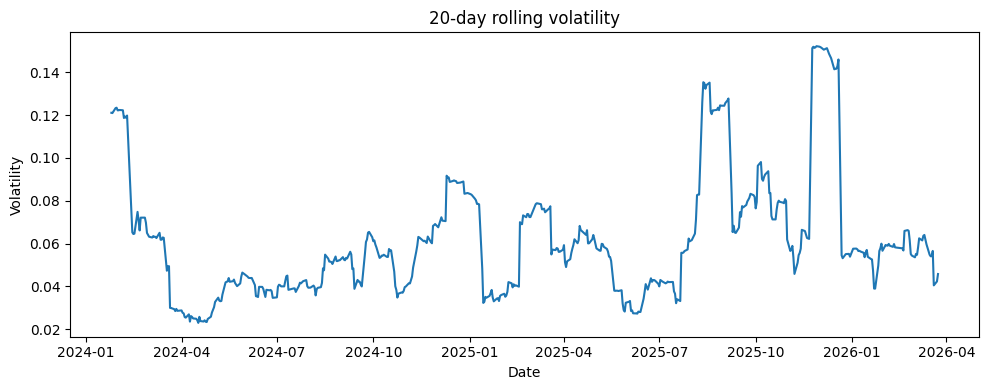

In [33]:
if equity is not None:
    rolling_window = 20
    equity['rolling_mean_return_20'] = equity['daily_return'].rolling(rolling_window).mean()
    equity['rolling_vol_20'] = equity['daily_return'].rolling(rolling_window).std()
    
    plt.figure(figsize=(10, 4))
    plt.plot(equity['trade_date'], equity['rolling_mean_return_20'])
    plt.title('20-day rolling mean return')
    plt.xlabel('Date')
    plt.ylabel('Return')
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(10, 4))
    plt.plot(equity['trade_date'], equity['rolling_vol_20'])
    plt.title('20-day rolling volatility')
    plt.xlabel('Date')
    plt.ylabel('Volatility')
    plt.tight_layout()
    plt.show()


## 8. Useful quick questions

In [34]:
if equity is not None:
    positive_ratio = (equity['daily_return'] > 0).mean()
    print('Positive day ratio:', positive_ratio)
    print('Final capital:', equity['end_capital'].iloc[-1])
    print('Max drawdown:', equity['drawdown'].min())

if trades is not None:
    print('\nTop 20 best trades')
    display(trades.nlargest(20, 'position_return'))
    print('Top 20 worst trades')
    display(trades.nsmallest(20, 'position_return'))


Positive day ratio: 0.5474060822898033
Final capital: 516098.516551682
Max drawdown: -0.9152061623778897

Top 20 best trades


,trade_date,symbol,target_5d,target_up_5d,pred_proba_up_5d,side,weight,position_return,start_capital,daily_portfolio_return
4783,2025-11-24,OIBR3,3.000000,1,0.579534,long,0.2,3.000000,2.477583e+05,0.607814
111,2024-01-15,SNSY3,2.303411,1,0.538872,long,0.2,2.303411,1.163227e+05,0.439242
3904,2025-07-22,TKNO4,1.316433,1,0.553363,long,0.2,1.316433,2.261615e+06,0.210351
2402,2024-12-10,FICT3,1.270270,1,0.524869,long,0.2,1.270270,4.103247e+05,0.291780
2862,2025-02-18,ONCO3,1.248062,1,0.532067,long,0.2,1.248062,9.139878e+05,0.268255
70,2024-01-09,NORD3,0.977401,1,0.646498,long,0.2,0.977401,8.968403e+04,0.146832
2350,2024-12-03,FHER3,0.959459,1,0.619482,long,0.2,0.959459,3.845348e+05,0.100696
5364,2026-02-20,FICT3,0.904762,1,0.523001,long,0.2,0.904762,8.652950e+05,0.159951
341,2024-02-19,PINE3,0.897960,1,0.561551,long,0.2,0.897960,1.345153e+05,0.209280
372,2024-02-22,PINE3,0.803607,1,0.539268,long,0.2,0.803607,1.724745e+05,0.190738


Top 20 worst trades


,trade_date,symbol,target_5d,target_up_5d,pred_proba_up_5d,side,weight,position_return,start_capital,daily_portfolio_return
4049,2025-08-11,RVEE3,1.980651,1,0.473076,short,0.2,-1.980651,1.499556e+06,-0.442102
4059,2025-08-12,RVEE3,1.501673,1,0.470393,short,0.2,-1.501673,8.365998e+05,-0.263418
4430,2025-10-03,PDGR3,-0.857143,0,0.611992,long,0.2,-0.857143,5.596774e+05,-0.255202
1861,2024-09-23,PDGR3,-0.833333,0,0.576300,long,0.2,-0.833333,3.884958e+05,-0.174347
4018,2025-08-06,RVEE3,0.829268,1,0.474068,short,0.2,-0.829268,1.962327e+06,-0.196778
1584,2024-08-14,AMER3,-0.757576,0,0.543485,long,0.2,-0.757576,4.008057e+05,-0.109779
1871,2024-09-24,PDGR3,-0.750000,0,0.593806,long,0.2,-0.750000,3.207627e+05,-0.116162
4443,2025-10-06,PDGR3,-0.750000,0,0.552987,long,0.2,-0.750000,4.168466e+05,-0.123908
4731,2025-11-14,OIBR3,-0.750000,0,0.565294,long,0.2,-0.750000,2.796848e+05,-0.158506
4422,2025-10-02,AMBP3,-0.738182,0,0.563311,long,0.2,-0.738182,6.417596e+05,-0.127902
